In [1]:
import os
import tarfile
from six.moves import urllib

In [2]:
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml/master/"
HOUSING_PATH = "datasets/housing"
HOUSING_URL = DOWNLOAD_ROOT + HOUSING_PATH + "/housing.tgz"

In [3]:
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

In [4]:
fetch_housing_data()

In [5]:
import pandas as pd

In [6]:
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    data = pd.read_csv(csv_path)
    return data

In [7]:
housing=load_housing_data()

### Data Analysis:

In [8]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [9]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [10]:
# Return the number of the repitions of every element.
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [11]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [12]:
# Draw a histogram:
# Another quick way to get a feel of the type of data you are dealing with is to plot a histogram for each numerical attribute

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt

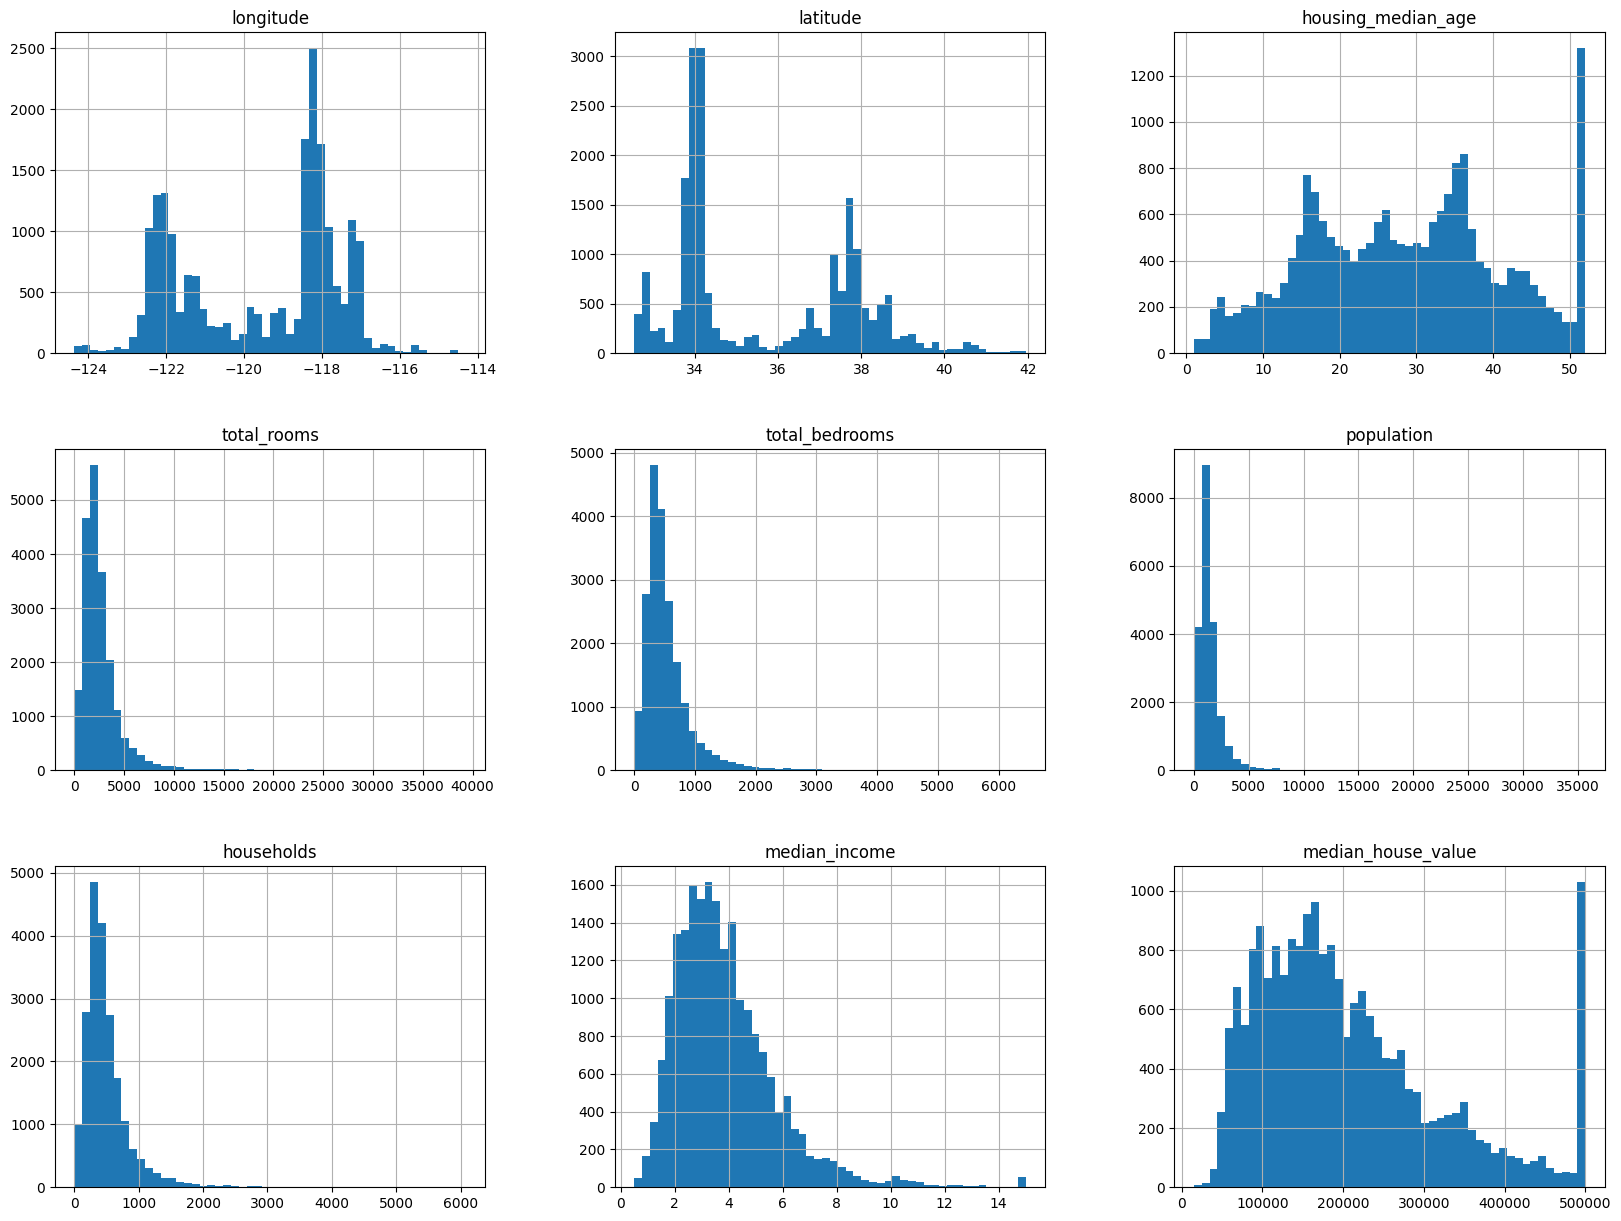

In [14]:
housing.hist(bins=50, figsize=(20, 15))
plt.show()

## Important Considerations on Processed Data and Labels

A good question to ask is: **what if the given data were processed**, for example, capped after \$500,000, and the labels were also processed accordingly?

We need to consult the team that will be using this model:

> **Do they require precise predictions beyond the \$500,000 cap?**

If the answer is **yes**, there are two possible approaches:

1. **Collect proper labels** for the districts whose labels were capped.
2. **Remove those districts** from the training set (and also from the test set),  
   since the system should not be penalized for predicting values beyond \$500,000 if such labels do not exist.

---

### Note on Skewed Right Histogram

A **skewed right histogram** means the data extend much farther to the right of the median than to the left.  
This indicates a distribution with a longer tail on the right side.


## Test Set

An important procedure:

- We need to **create a test set** and set it aside.
- **Never look at the test set** during model training or tuning.

### 📌 Main Points: Why You Should Set Aside the Test Set Early

- *Set aside a test set early*, even before exploring the data deeply.
- Although it feels wrong to do this before analyzing the data, it's important to avoid bias.
- *The human brain is great at finding patterns*, even when they’re not real.
- If you look at the *test set too early*, you might:
  - Find a pattern by chance
  - Choose or tune a model based on that accidental pattern
- This leads to *overfitting* and an *unrealistically optimistic test score*.
- This mistake is called *data snooping bias*.
- As a result, your model may *perform worse in the real world* than expected.

In [15]:
import numpy as np

In [16]:
def shuffle_and_split_data(data, test_ratio, rangenerator):
    shuffled_indices=rangenerator.permutation(len(data))
    test_set_size=int(len(data)*test_ratio)
    test_indices=shuffled_indices[:test_set_size]
    train_indices=shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [17]:
rangenerator=np.random.default_rng(seed=42)
train_set, test_set=shuffle_and_split_data(housing, 0.2, rangenerator)
len(test_set)

4128

## Test Set Contamination Issue

We now face a new problem:

- The **test set is randomly generated** from the dataset.
- But what if we later **update our data**?  
  For example:
  - Adding new rows  
  - Updating existing rows with more precise data  
  - Applying new preprocessing steps  

### The Problem

If we re-split the dataset randomly after such updates:

- **Data leakage may occur**:
  - Some data from the **original training set** may end up in the **new test set**
  - Some data from the **original test set** may now be in the **training set**

This undermines the purpose of having a clean, untouched test set.

---

### Solution

We need a **proper strategy** to avoid contamination:

- **Create and store a fixed test set early** in the pipeline
- When updating or modifying the dataset:
  - **Ensure the test set remains unchanged**
  - **Apply the same preprocessing steps** to both training and test sets  
  - Avoid introducing test samples into training, and vice versa

This ensures the test set continues to provide a valid, unbiased evaluation of the model’s generalization ability.


In [18]:
from zlib import crc32

In [19]:
def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio*2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids=data[id_column]
    in_test_set=ids.apply(lambda id_:is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [20]:
housing_with_id = housing.reset_index()
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

## Maintaining Data Integrity: Stable Identifiers

A new challenge can arise:

> We must **not remove data** and **must not change the index** of the rows.

This becomes critical when:

- Updating or modifying the dataset
- Ensuring consistent splitting between training and test sets over time

---

### The Solution: Use a Stable Identifier

To maintain integrity and avoid data leakage or mismatch:

- **Find a fixed, stable column** in your dataset that uniquely identifies each row  
  Examples:
  - `latitude` and `longitude` (combined can serve as a geolocation-based identifier)
  - A unique `property_id`, if available
  - Any field that remains unchanged across data updates

- Use this identifier to:
  - **Consistently assign data to training/test sets**
  - **Track changes** to the same entity over time

---

### Benefits

- Ensures no accidental reshuffling or overlap between training and test sets
- Maintains reproducibility across dataset versions


In [21]:
housing_with_id["id"]=(housing["longitude"] * 1000 + housing["latitude"])
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")

In [22]:
"""
The power of train_test_split from sklearn that it can split multiple datasets at the same time with the same indicies.
"""
from sklearn.model_selection import train_test_split

In [23]:
trian_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

### 📊 Summary: Stratified Sampling vs. Random Sampling

### 🧪 Random Sampling
- Works **okay** for large datasets.
- **Risky** for small datasets → can introduce **sampling bias**.
- May **accidentally over- or under-represent** certain important groups.

### 🎯 Real-World Example
- A survey company calling 1,000 people shouldn't pick names randomly.
- Example: US population is ~51.1% female, ~48.9% male.
- A good sample should reflect this proportion (e.g., 511 women, 489 men).
- If selected randomly, there's a ~10.7% chance of a **gender-skewed sample**.

### ✅ Stratified Sampling
- Divide the population into **homogeneous subgroups** (called **strata**).
- Sample from each stratum **proportionally** to its size in the population.
- Produces a **representative test/train split** with less bias.

### 💡 Applying to Housing Data
- Experts say **median_income** is key for predicting housing prices.
- Since it's a **continuous** attribute, you must:
  - Convert it into **discrete income categories** (bins).
  - Then apply stratified sampling based on these categories.

### 📈 Important Tips
- Avoid creating **too many strata** — keep it manageable.
- Each stratum must have **enough data points** to give reliable results.


In [24]:
housing["income_cat"] = pd.cut(housing["median_income"], 
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf], 
                               labels=[1, 2, 3, 4, 5])

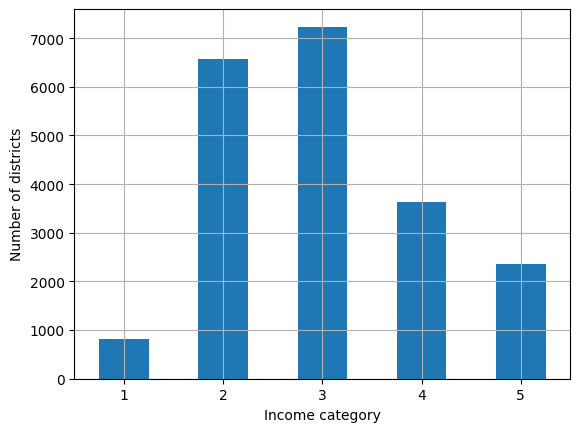

In [25]:
cat_counts=housing["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [26]:
strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

In [27]:
(strat_test_set["income_cat"].value_counts()/len(strat_test_set)).sort_index()

income_cat
1    0.039971
2    0.318798
3    0.350533
4    0.176357
5    0.114341
Name: count, dtype: float64

In [28]:
# We are not in need of income_cat column, so we will drop it.
for set_ in (strat_train_set, strat_test_set):
 set_.drop("income_cat", axis=1, inplace=True)

## Explore and Visualize the Data to Gain Insights

If the training set is very large, you may want to sample an exploration set to make manipulations easy and fast during the exploration phase.

Since you’re going to experiment with various transformations of the full training set, you should make a copy of the original so you can revert to it afterwards.


In [29]:
housing = strat_train_set.copy()

### Visualizing Geographical Data
In this block, we will start to see how it goes from the plain graph, to a good graph where we can gain insights from it

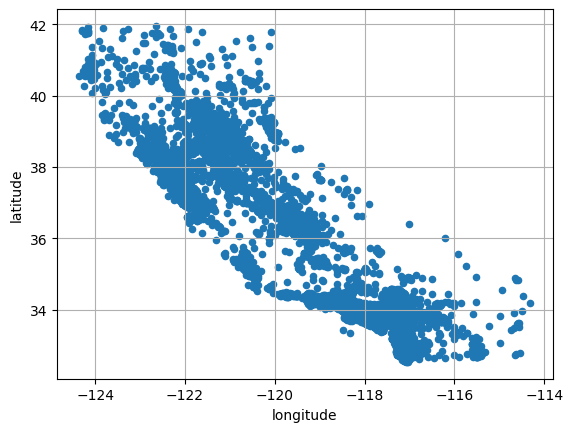

In [30]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True);

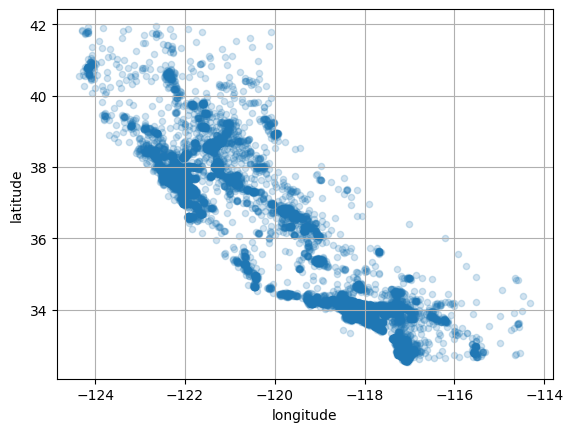

In [31]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2);

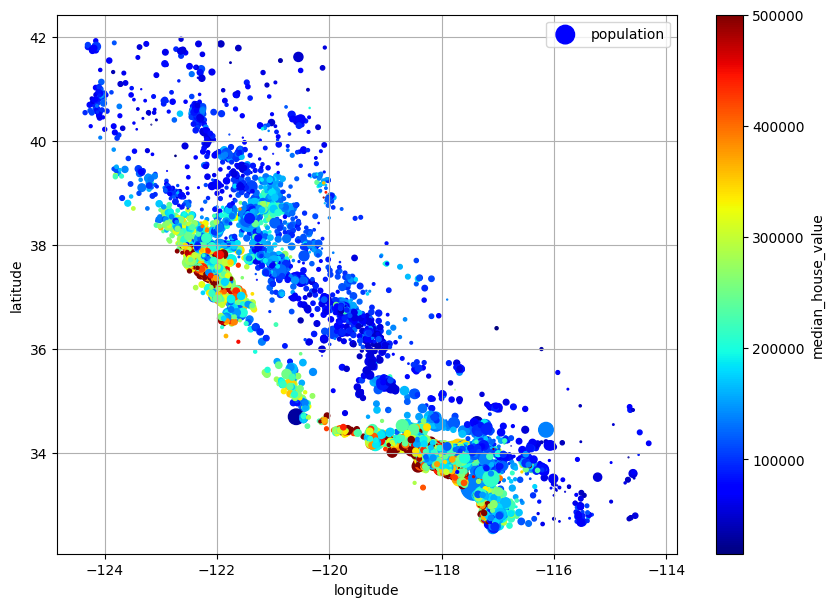

In [32]:
# The radius of each circle represents the district’s population (option s)
# the color represents the price (option c)

housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, 
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7));

### Look for Correlations

In [33]:
corr_matrix = housing.drop(["ocean_proximity"], axis=1).corr()

In [34]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

In [35]:
from pandas.plotting import scatter_matrix

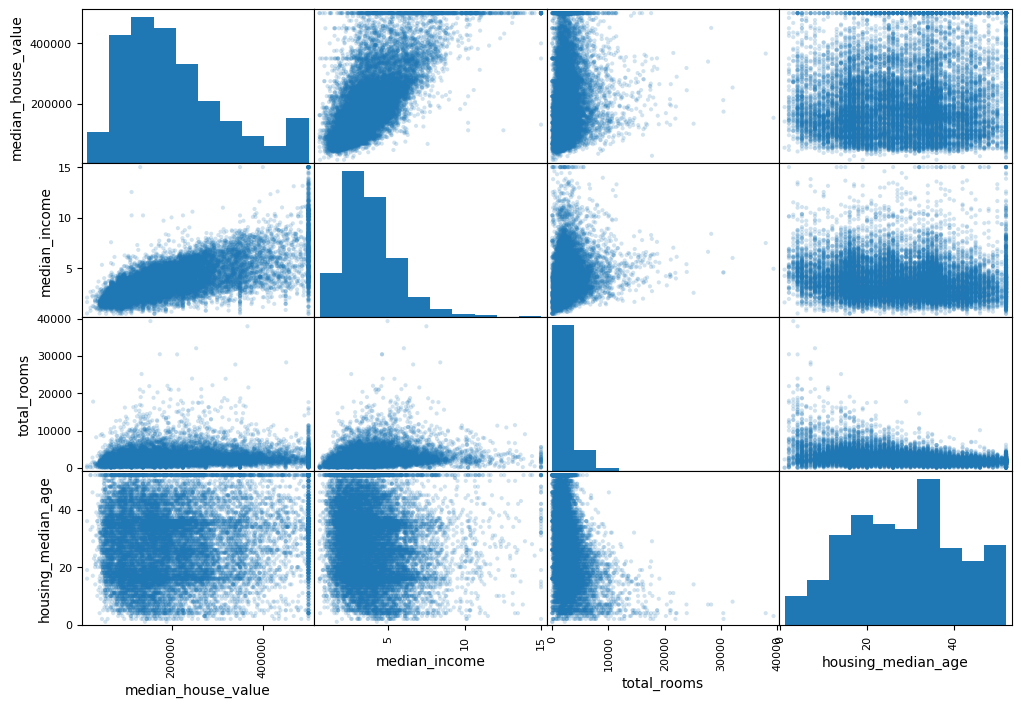

In [36]:
attributes = ["median_house_value", "median_income", "total_rooms",
"housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8), alpha=0.2);

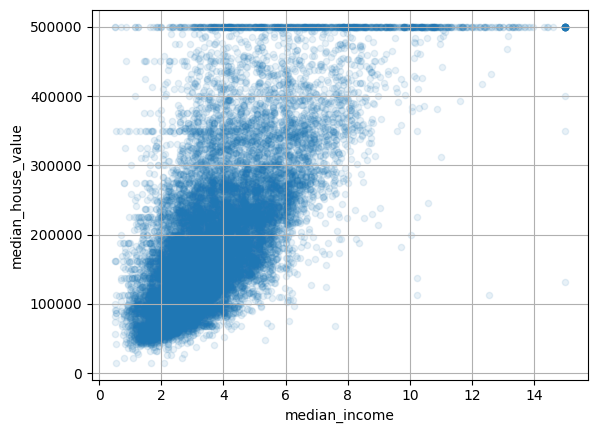

In [37]:
# Looking at the correlation scatterplots, it seems like the most promising attribute
# to predict the median house value is the median income.
"""
This plot reveals a few things. First, the correlation is indeed quite strong; you can
clearly see the upward trend, and the points are not too dispersed. Second, the price
cap you noticed earlier is clearly visible as a horizontal line at $500,000. But the
plot also reveals other less obvious straight lines: a horizontal line around $450,000,
another around $350,000, perhaps one around $280,000, and a few more below that.

You may want to try removing the corresponding districts to prevent your algorithms
from learning to reproduce these data quirks.
"""
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid=True);

###  Experiment with Attribute Combinations

In [38]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [39]:
corr_matrix = housing.drop(["ocean_proximity"], axis=1).corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
rooms_per_house       0.146255
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
people_per_house     -0.021991
population           -0.026882
longitude            -0.047466
latitude             -0.142673
bedrooms_ratio       -0.259952
Name: median_house_value, dtype: float64

## Prepare the Data for Machine Learning Algorithms

In [40]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

#### NOTE: The difference between  
1. `housing_labels = strat_train_set["median_house_value"].copy()`
   - **Creates a separate copy** of the `"median_house_value"` column.  
   - If you later modify `housing_labels`, the original `strat_train_set` will **not** be affected.  
   - Safe to use if you plan to change `housing_labels` without touching the original DataFrame. 
2. `housing_labels = strat_train_set["median_house_value"]`   
    - **Does not create a copy** — it’s just another reference to the same data in memory.  
   - If you modify `housing_labels`, you will also modify the `"median_house_value"` column inside `strat_train_set` (and vice versa).  
   - Faster and uses less memory, but riskier if you want to preserve the original data.  


### Clean the Data

In [41]:
from sklearn.impute import SimpleImputer

In [42]:
imputer = SimpleImputer(strategy="median")

In [43]:
housing_num = housing.select_dtypes(include=[np.number])
housing_num.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964


In [44]:
imputer.fit(housing_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [45]:
print(imputer.statistics_)
housing_num.median().values

[-118.51      34.26      29.      2119.       433.      1164.
  408.         3.54155]


array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [46]:
X = imputer.transform(housing_num)

In [47]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

### Handling Text and Categorical Attributes

In [48]:
housing_cat = housing[["ocean_proximity"]]

In [49]:
housing_cat.head()

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN


In [50]:
from sklearn.preprocessing import OrdinalEncoder

In [51]:
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [52]:
housing_cat_encoded[:8]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.]])

In [53]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

#### Ordinal Encoding Problems:

- ML algorithms will assume that two nearby values are more similar than two distant values.  
- This works fine for **ordered categories** (e.g., “bad”, “average”, “good”, “excellent”).  
- This assumption is **not valid** for the `ocean_proximity` column  
  - Example: categories `0` and `4` are more similar than `0` and `1`.  
- **Solution**: create one binary attribute per category (one-hot encoding).  
  - Example:  
    - `1` when the category is `<1H OCEAN`, else `0`  
    - `1` when the category is `INLAND`, else `0`  
    - And so on for each category  
- This is called **one-hot encoding** because:  
  - Only one attribute will be `1` (**hot**)  
  - All others will be `0` (**cold**)


In [54]:
from sklearn.preprocessing import OneHotEncoder

In [55]:
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [56]:
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(16512, 5))

In [57]:
# Another Example to get OneHotEncoding:
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
pd.get_dummies(df_test)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


#### Why use OneHotEncoder instead of get_dummies?

- It looks nice and simple, so why not use it instead of OneHotEncoder?
- The advantage of OneHotEncoder is that it **remembers which categories it was trained on**.
- This is very important because once your model is in production, it should be fed **exactly the same features as during training**:
  - No more features
  - No less features


#### Handling Large Number of Categories in Categorical Attributes

- If a categorical attribute has a large number of possible categories (e.g., country code, profession, species), one-hot encoding will:
  - Result in a large number of input features.
  - Potentially slow down training.
  - Possibly degrade model performance.
- If this happens, consider these alternatives:
  - Replace the categorical input with useful numerical features related to the categories. For example:
    - Replace the `ocean_proximity` feature with the distance to the ocean.
    - Replace a country code with the country’s population and GDP per capita.
  - Use one of the encoders from the `category_encoders` package available on GitHub.
  - For neural networks, replace each category with a learnable, low-dimensional vector called an **embedding**.
- This approach is an example of **representation learning**.


In [58]:
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [59]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

### Feature Scaling and Transformation
- One of the most important transformations to apply to your data is **feature scaling**.  
- Most machine learning algorithms don’t perform well when input numerical attributes have **very different scales**.  
- Example from housing data:  
  - Total number of rooms ranges from **6 to 39,320**.  
  - Median incomes range from **0 to 15**.  
- Without scaling:  
  - Models may **ignore smaller-scale features** like median income.  
  - Models may **focus more** on larger-scale features like number of rooms.  
- **Fit scalers only on the training data** — never use `fit()` or `fit_transform()` on validation, test, or new data.  
- After fitting the scaler on the training set:  
  - Use `transform()` for the validation set, test set, and new data.  
- **Important notes**:  
  - Training set values will be scaled to the specified range.  
  - New data with **outliers** may be scaled **outside the range**.  
  - To prevent this, set the **`clip`** hyperparameter to `True`.  

- **`clip=True`** ensures scaled values stay within the specified range, even for outliers.  

### Example (MinMaxScaler with `feature_range=(0, 1)`):  

**Training data**: `5, 10, 15`  
- Min = `5`, Max = `15`  
- Scaling formula:  
  \[
  x' = \frac{x - 5}{15 - 5}
  \]  

**Without `clip=True`**:  
- New input: `20`  
- Scaling: `(20 - 5) / (15 - 5) = 1.5` → **outside range**  

**With `clip=True`**:  
- New input: `20`  
- Scaling result: `1.0` (clipped to max of the range)  

**Summary**:  
- Without clip → scaled values can be `< 0` or `> 1`.  
- With clip → scaled values are forced into the min/max range.  


In [61]:
from sklearn.preprocessing import MinMaxScaler

In [62]:
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

- **Min-max scaling** (often called **normalization**) is the simplest scaling method.  
- Process for each attribute:  
  1. Subtract the **minimum value**.  
  2. Divide by the **difference between the max and min**.  
- Result: values range from **0 to 1** by default.  
- **Scikit-Learn** provides the `MinMaxScaler` transformer for this.  
- **`feature_range`** hyperparameter:  
  - Lets you change the range from the default (0–1).  
  - Example: neural networks often work best with **zero-mean inputs**, so a range of **–1 to 1** may be preferable.  


In [63]:
from sklearn.preprocessing import StandardScaler

In [64]:
std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

- **Standardization**:  
  1. Subtracts the **mean value** → standardized values have a **zero mean**.  
  2. Divides the result by the **standard deviation** → standardized values have a **standard deviation of 1**.  
- **Differences from min-max scaling**:  
  - Does **not** restrict values to a specific range.  
  - Is **less affected by outliers**.  
- **Example**:  
  - Suppose a district has a median income of `100` (by mistake) instead of the usual `0–15`.  
  - **Min-max scaling** (range 0–1) would map this outlier to `1` and compress all other values to `0–0.15`.  
  - **Standardization** would be **less influenced** by the outlier and preserve the spread of other values.  

- **Scaling sparse matrices** without converting to dense:  
  - Use `StandardScaler` with `with_mean=False`.  
  - This will **divide by the standard deviation** but **not subtract the mean**.  
  - Reason: subtracting the mean would **break sparsity** (introduce non-zero values where there were zeros).  


- **Features with heavy tails**:  
  - Heavy tail → values far from the mean are **not exponentially rare**.  
  - **Problem**: Min-max scaling and standardization will **squash most values** into a small range.  
  - **Impact**: Machine learning models **perform poorly** on such features.  

- **Solution**: Transform the feature **before scaling** to:  
  1. **Shrink the heavy tail**.  
  2. Make the distribution **roughly symmetrical**.  

- **Common transformations**:  
  - Positive features with a heavy tail to the right:  
    - Take **square root** or raise the feature to a **power between 0 and 1**.  
  - Features with very long/heavy tails (e.g., power law distribution):  
    - Take the **logarithm** of the feature.  

- **Example – population feature**:  
  - Follows roughly a **power law**:  
    - Districts with 10,000 inhabitants are only **10× less frequent** than districts with 1,000 inhabitants (linear drop, not exponential).  
  - Taking the **log** of population makes it **closer to a Gaussian distribution**, improving model performance.  


#### Transforming Multimodal Features  

- **Multimodal distribution**:  
  A distribution with **two or more clear peaks** (modes).  
  Example: `housing_median_age`.  

---

#### 1️⃣ Approach: Bucketizing as Categories  
- **Step**: Split feature values into **ranges** (buckets).  
- **Treat bucket IDs as categories** (not numeric values).  
  - Encode with **OneHotEncoder**.  
  - Keep the number of buckets small for model efficiency.  
- **Benefit**:  
  - Lets the regression model learn **different rules** for different ranges.  
  - Example: Houses built ~35 years ago may have an outdated style → lower price than expected by age alone.  

---

#### 2️⃣ Approach: RBF (Radial Basis Function) Similarity  
- **Idea**: Create a **new feature for each mode** to measure closeness to that mode.  
- **Common choice**: Gaussian RBF  
$$
\text{similarity}(x, c) = \exp(-\gamma (x - c)^2)
$$ 
  - **x** = feature value  
  - **c** = mode (center)  
  - **γ** (gamma) = controls how fast similarity drops with distance.  
- **Output**: Smooth value in **[0, 1]**  
  - High → near the mode.  
  - Low → far from the mode.  
- **Why it works**: Helps the model handle **each peak separately** without abrupt bucket boundaries.  


In [65]:
from sklearn.metrics.pairwise import rbf_kernel

In [66]:
age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

#### Adding Transformers and Handling Label Edits

When we add transformers, any modifications we make to our labels will be reflected in the training process.  
The model will learn based on these transformed labels, so the outputs will also be transformed.  

To retrieve the original data, we need to apply the **inverse transformation** to the model’s outputs.


In [73]:
from sklearn.linear_model import LinearRegression
target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())
model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[["median_income"]].iloc[:5]  # pretend this is new data
scaled_predictions = model.predict(some_new_data)
predictions_ = target_scaler.inverse_transform(scaled_predictions)

In [78]:
from sklearn.compose import TransformedTargetRegressor
model = TransformedTargetRegressor(LinearRegression(), transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(some_new_data)

### Custom Transformers

In [79]:
from sklearn.preprocessing import FunctionTransformer

In [80]:
"""
For transformations that don’t need training, you can write a simple function that takes a NumPy array and returns the transformed array. 
For example, features with heavy-tailed distributions can be transformed using the logarithm to reduce skewness.
"""
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])

In [82]:
# Your transformation function can take hyperparameters as additional arguments. 
rbf_transformer = FunctionTransformer(rbf_kernel,
                                      kw_args=dict(Y=[[35.]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])

In [83]:
"""
Also note that
rbf_kernel() does not treat the features separately. If you pass it an array withctwo features, 
it will measure the 2D distance (Euclidean) to measure similarity. 
For example, here’s how to add a feature that will measure the geographic similarity
between each district and San Francisco
"""
sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel,
kw_args=dict(Y=[sf_coords], gamma=0.1))
sf_simil = sf_transformer.transform(housing[["latitude", "longitude"]])

**FunctionTransformer** is very handy, but what if you want your transformer to be **trainable**, learning some parameters in the `fit()` method and using them later in the `transform()` method?  

For this, you need to write a **custom class**. Scikit-Learn relies on **duck typing**, so the class does **not** have to inherit from any particular base class. All it needs are three methods:  

- `fit()` (must return `self`)  
- `transform()`  
- `fit_transform()`  

You can get `fit_transform()` for free by simply adding **`TransformerMixin`** as a base class: the default implementation will just call `fit()` and then `transform()`.  

If you also add **`BaseEstimator`** as a base class (and avoid using `*args` and `**kwargs` in your constructor), you will get two extra methods:  

- `get_params()`  
- `set_params()`  

These are useful for **automatic hyperparameter tuning**.


In [98]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):  # no *args or **kwargs!
        self.with_mean = with_mean

    def fit(self, X, y=None):  # y is required even though we don't use it
        X = check_array(X)  # checks that X is an array with finite float values
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1]  # every estimator stores this in fit()
        return self  # always return self!

    def transform(self, X):
        check_is_fitted(self)  # looks for learned attributes (with trailing _)
        X = check_array(X)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_

In [86]:
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
    
    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!
    
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
        
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [87]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]],
                                           sample_weight=housing_labels)

In [101]:
 from sklearn.pipeline import Pipeline

In [103]:
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

In [122]:
num_pipeline.named_steps["impute"]

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [123]:
from sklearn.pipeline import make_pipeline

In [128]:
num_pipeline_fun = make_pipeline(SimpleImputer(strategy="mean"), SimpleImputer(strategy="mean"), StandardScaler())

In [129]:
# It shows the non-default arguments values.
num_pipeline_fun.named_steps

{'simpleimputer-1': SimpleImputer(),
 'simpleimputer-2': SimpleImputer(),
 'standardscaler': StandardScaler()}

In [131]:
from sklearn.compose import ColumnTransformer

In [136]:
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"),
                             OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

In [137]:
from sklearn.compose import make_column_selector, make_column_transformer

In [138]:
preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

In [139]:
housing_prepared = preprocessing.fit_transform(housing)

In [158]:
# The full code for the pipeline, that will help to get the data from the start to the end:
from sklearn.preprocessing import FunctionTransformer

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

cat_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"),
                             OneHotEncoder(handle_unknown="ignore"))
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )

def log_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="mean"),
        FunctionTransformer(np.log, feature_names_out="one-to-one"),
        StandardScaler()
    )

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

preprocessing = ColumnTransformer(
    [
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]), 
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline(),  ["total_bedrooms", "total_rooms", "population", "households", "median_income"]),
        ("geo", cluster_simil, ["longitude", "latitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ]
, remainder=default_num_pipeline)

In [159]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 24)

In [169]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)